# Baseline model using RS-42 full dataset

In [5]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best,
)
from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
    AdaBoostClassifier,
    PRFClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 MACCS_keys,
                                 ECFP_counts,
                                 PathFP,
                                 PhyschemDescriptors,
                                 CompositeDescriptor,
                                 UnscaledPhyschemDescriptors,
                                 JazzyDescriptors,
                                 PhyschemDescriptors,
                                 Avalon)

from optunaz.utils.preprocessing.splitter import Stratified
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn
from sklearn.metrics import *

QSARtunaModel(predictor=RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=1.0,
                       n_estimators=142, n_jobs=-1, random_state=42), descriptor=ECFP_counts(name='ECFP_counts', parameters=ECFP_counts.Parameters(radius=3, useFeatures=True, nBits=2048)), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\RS_datasets\\tobramycin_train_full_rs42.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\RS_datasets\\tobramycin_test_full_rs42.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representati

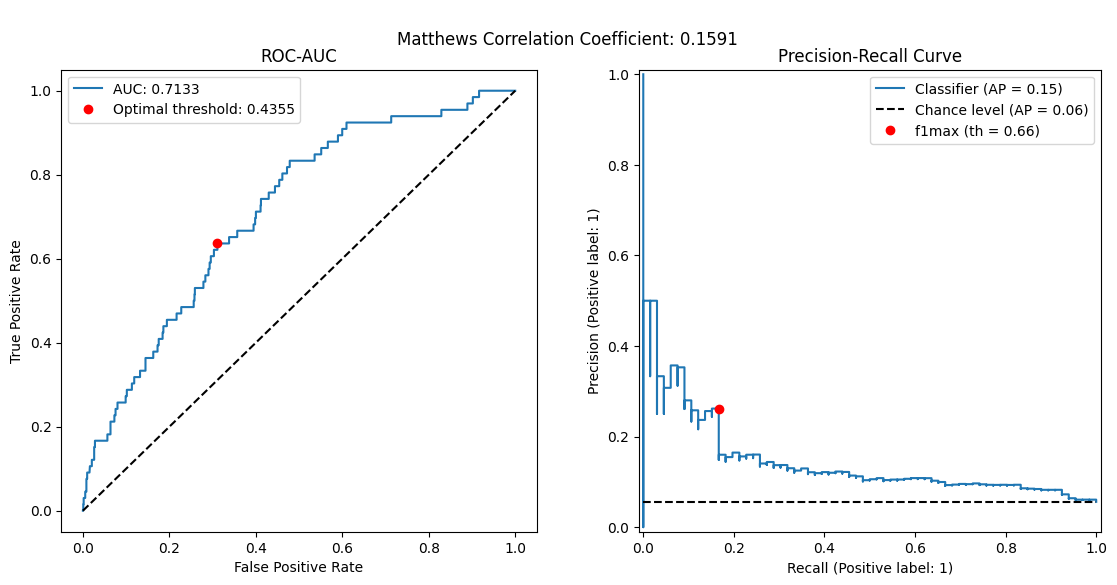

In [3]:
config = OptimizationConfig(
        data=Dataset(
            input_column='Structure',
            response_column='Class',
            training_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_full_rs42.csv',
            test_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_full_rs42.csv',
        ),
        descriptors=[
            ECFP.new(),
            ECFP_counts.new(),
            MACCS_keys.new(),
            PhyschemDescriptors.new(),
            UnscaledPhyschemDescriptors.new(),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP_counts.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    MACCS_keys.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            )
        ],
        algorithms=[
            RandomForestClassifier.new(),
            SVC.new(),
            LogisticRegression.new(),
            KNeighborsClassifier.new(),
        ],
        settings=OptimizationConfig.Settings(
            mode=ModelMode.CLASSIFICATION,
            cross_validation=10,
            cv_split_strategy=Stratified(),
            n_trials=200,
            n_startup_trials=50,
            direction=OptimizationDirection.MAXIMIZATION,
            random_seed=42,
            n_jobs=-1
        ),
    )

# base = optimize(config, study_name='base_3')

# build_best(buildconfig_best(base), r"M:\ML_scripts\MODEL DATA\models\RS42_baseline.pkl")

with open(r"M:\ML_scripts\MODEL DATA\models\RS42_baseline.pkl", "rb") as m:
    model = pickle.load(m)

print(model)

fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         # create plots for curves

x = np.linspace(0,1)

test_data = pd.read_csv(config.data.test_dataset_file)  # load the test data
test_smiles = test_data[config.data.input_column]       # test structures
y_true = test_data[config.data.response_column]         # test ground truth labels

y_pred = model.predict_from_smiles(test_smiles)         # model predictions on test set structures

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) # false positive rate, true positive rate and thresholds
auc = np.trapz(tpr, fpr)                                     # AUC using trapezoidal rule
plt.plot(fpr, tpr)                                           # plot the ROC curve
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}")   # matthews CC
# print(classification_report(y_true, y_pred_bin))              # classification report
# print(cm(y_true, y_pred_bin))                                 # confusion matrix

# Plotting the Precision-Recall curve

pos_label = 1 
name = "TM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)     # precision, recall and thresholds
f1_scores = 2 * recall * precision / (recall + precision)                                       # https://stats.stackexchange.com/questions/596807/how-to-get-the-threshold-from-precisionrecalldisplay
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# non-RS dataset baseline

Could not compute descriptors for 2 SMILES, ignoring them in Scaler.


QSARtunaModel(predictor=RandomForestClassifier(class_weight='balanced', max_depth=4, max_features=1.0,
                       n_estimators=219, n_jobs=-1, random_state=42), descriptor=ECFP(name='ECFP', parameters=ECFP.Parameters(radius=3, nBits=2048, returnRdkit=True)), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\TOBRAMYCIN_TRAIN_SET_var_corr_scal.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\TOBRAMYCIN_TEST_SET_SCALED_NEW.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representation': False, 'probabilistic_thresho

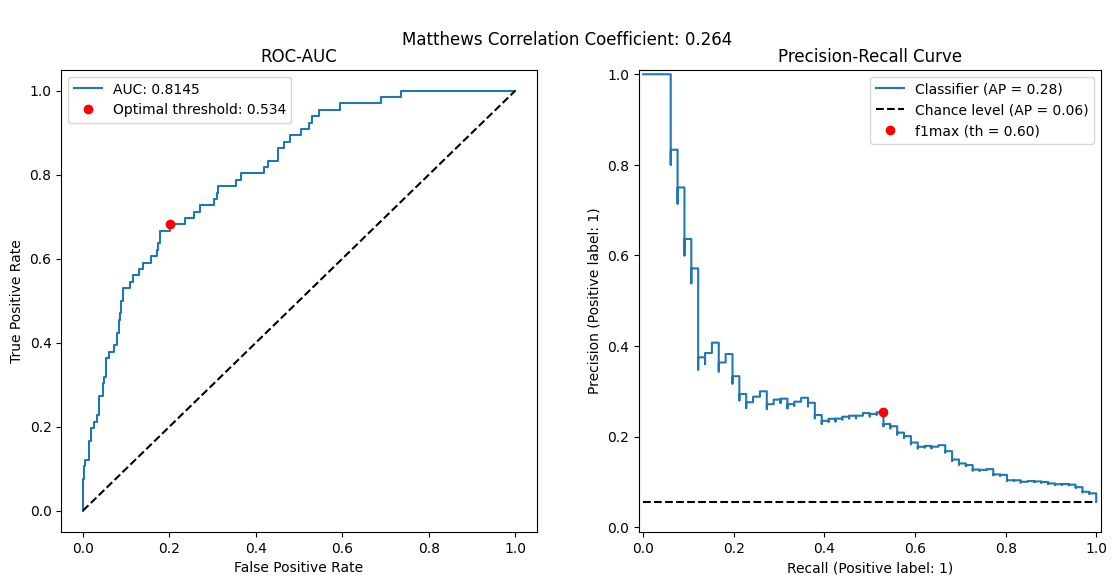

In [ ]:
config1 = OptimizationConfig(
    data=Dataset(
        input_column="Structure",  # Typical names are "SMILES" and "smiles".
        response_column="Class",  # Often a specific name (like here), or just "activity".
        training_dataset_file=r"M:\ML_scripts\MODEL DATA\TOBRAMYCIN_TRAIN_SET_var_corr_scal.csv", # undersampled and processed training dataset
        test_dataset_file=r"M:\ML_scripts\MODEL DATA\TOBRAMYCIN_TEST_SET_SCALED_NEW.csv",  # Hidden during optimization.
    ),
    descriptors=[
        ECFP.new(returnRdkit=True),
        ECFP_counts.new(),
        MACCS_keys.new(),
        PathFP.new(),
        PhyschemDescriptors.new(),
        JazzyDescriptors.new(),
        Avalon.new()
    ],
    algorithms=[
        LogisticRegression.new(),
        RandomForestClassifier.new(),
        KNeighborsClassifier.new(),
        SVC.new(),
    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        n_trials=200,  # Total number of trials.
        n_startup_trials=50,  # Number of startup ("random") trials.
        random_seed=42, # Seed for reproducability
        direction=OptimizationDirection.MAXIMIZATION,
        n_jobs=-1,
    ),
)

base = optimize(config1, study_name='base_1')

build_best(buildconfig_best(base), r"M:\ML_scripts\MODEL DATA\models\non-sampled_base_model.pkl")

with open(r"M:\ML_scripts\MODEL DATA\models\non-sampled_base_model.pkl", "rb") as m:
    model1 = pickle.load(m)

print(model1)

fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         # create plots for curves

x = np.linspace(0,1)

test_data = pd.read_csv(config1.data.test_dataset_file)  # load the test data
test_smiles = test_data[config1.data.input_column]       # test structures
y_true = test_data[config1.data.response_column]         # test ground truth labels

y_pred = model1.predict_from_smiles(test_smiles)         # model predictions on test set structures

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) # false positive rate, true positive rate and thresholds
auc = np.trapz(tpr, fpr)                                     # AUC using trapezoidal rule
plt.plot(fpr, tpr)                                           # plot the ROC curve
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}")   # matthews CC
# print(classification_report(y_true, y_pred_bin))              # classification report
# print(cm(y_true, y_pred_bin))                                 # confusion matrix

# Plotting the Precision-Recall curve

pos_label = 1 
name = "TM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)     # precision, recall and thresholds
f1_scores = 2 * recall * precision / (recall + precision)                                       # https://stats.stackexchange.com/questions/596807/how-to-get-the-threshold-from-precisionrecalldisplay
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true, y_pred, pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();